# 1 Install and import packages

In [3]:
!pip install -q pandas numpy scikit-learn catboost matplotlib


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from catboost import CatBoostClassifier, CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 2 Load the saved CatBoost model and helper functions

In [9]:
MODEL_PATH = "CatBoost_Optuna_Tuned.cbm"
DATA_PATH = "cleaned_data.csv"
TARGET_COL = "Accident_Severity"

SERIOUS_WEIGHT = 0.5
FATAL_WEIGHT = 1.0

GRID_DECIMALS = 2   

def add_cyclical_features(frame):
    df = frame.copy()

    if "acc_month" in df.columns:
        df["acc_month_sin"] = np.sin(2 * np.pi * df["acc_month"] / 12)
        df["acc_month_cos"] = np.cos(2 * np.pi * df["acc_month"] / 12)
        df = df.drop(columns=["acc_month"])

    if "acc_dayofweek" in df.columns:
        df["acc_dayofweek_sin"] = np.sin(2 * np.pi * df["acc_dayofweek"] / 7)
        df["acc_dayofweek_cos"] = np.cos(2 * np.pi * df["acc_dayofweek"] / 7)
        df = df.drop(columns=["acc_dayofweek"])

    return df

def load_saved_model(model_path):
    model = CatBoostClassifier()
    model.load_model(model_path)
    return model

def normalize_label(x):
    s = str(x).strip().lower()
    if s in {"0", "0.0", "slight"}:
        return "slight"
    if s in {"1", "1.0", "serious"}:
        return "serious"
    if s in {"2", "2.0", "fatal"}:
        return "fatal"
    return s

def infer_probability_columns(prob_df):
    # Named case
    if "prob_Serious" in prob_df.columns and "prob_Fatal" in prob_df.columns:
        return "prob_Serious", "prob_Fatal"

    # Numeric class case
    if "prob_1" in prob_df.columns and "prob_2" in prob_df.columns:
        return "prob_1", "prob_2"

    # Fallback: ordered [slight, serious, fatal]
    cols = list(prob_df.columns)
    return cols[1], cols[2]

def score_accidents_with_saved_model(df, model_path, target_col=TARGET_COL):
    model = load_saved_model(model_path)

    X = df.drop(columns=[target_col], errors="ignore").copy()
    X = add_cyclical_features(X)

    expected_cols = list(model.feature_names_)
    missing_cols = [c for c in expected_cols if c not in X.columns]
    if missing_cols:
        raise ValueError(f"Missing columns required by saved model: {missing_cols}")

    extra_cols = [c for c in X.columns if c not in expected_cols]
    if extra_cols:
        X = X.drop(columns=extra_cols)

    X = X[expected_cols].copy()

    pred_raw = np.array(model.predict(X)).reshape(-1)
    pred_labels = []
    for v in pred_raw:
        n = normalize_label(v)
        if n == "slight":
            pred_labels.append("Slight")
        elif n == "serious":
            pred_labels.append("Serious")
        elif n == "fatal":
            pred_labels.append("Fatal")
        else:
            pred_labels.append(str(v))

    try:
        class_names = [str(c) for c in model.classes_]
    except:
        class_names = ["0", "1", "2"]

    proba = model.predict_proba(X)
    prob_cols = [f"prob_{c}" for c in class_names]
    prob_df = pd.DataFrame(proba, columns=prob_cols, index=df.index)

    serious_col, fatal_col = infer_probability_columns(prob_df)

    scored = df.copy()
    scored["predicted_class"] = pred_labels
    scored["serious_risk_prob"] = prob_df[serious_col].values
    scored["fatal_risk_prob"] = prob_df[fatal_col].values
    scored["hotspot_score"] = (
        SERIOUS_WEIGHT * scored["serious_risk_prob"] +
        FATAL_WEIGHT * scored["fatal_risk_prob"]
    )

    return pd.concat([scored, prob_df], axis=1)

# 3 Load the data and score all historical accidents

In [12]:
df = pd.read_csv(DATA_PATH)

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

print("Raw data shape:", df.shape)

scored_df = score_accidents_with_saved_model(df, MODEL_PATH, target_col=TARGET_COL)

print("Scored data shape:", scored_df.shape)
display(scored_df.head())

Raw data shape: (660579, 17)
Scored data shape: (660579, 24)


,Accident_Severity,Latitude,Light_Conditions,Longitude,Number_of_Casualties,Number_of_Vehicles,Road_Surface_Conditions,Road_Type,Urban_or_Rural_Area,acc_year,...,Vehicle_Group,Weather_Simple,Regional_Risk_Score,predicted_class,serious_risk_prob,fatal_risk_prob,hotspot_score,prob_0,prob_1,prob_2
0,Serious,51.506187,Darkness - lights lit,-0.209082,1.0,2.0,Dry,Single carriageway,Urban,2019,...,Car,Fine,0.004236,Slight,0.135539,0.005539,0.073309,0.858922,0.135539,0.005539
1,Serious,51.495029,Daylight,-0.173647,1.0,2.0,Wet or damp,Single carriageway,Urban,2019,...,Car,Adverse,0.004236,Slight,0.082736,0.002463,0.043831,0.914801,0.082736,0.002463
2,Serious,51.517715,Darkness - lighting unknown,-0.210215,1.0,3.0,Dry,Single carriageway,Urban,2019,...,Car,Fine,0.004236,Slight,0.131806,0.007716,0.073619,0.860478,0.131806,0.007716
3,Serious,51.495478,Daylight,-0.202731,1.0,4.0,Dry,Single carriageway,Urban,2019,...,Public_Transport,Fine,0.004236,Slight,0.118144,0.007957,0.067029,0.873899,0.118144,0.007957
4,Slight,51.488576,Darkness - lights lit,-0.192487,1.0,2.0,Dry,Single carriageway,Urban,2019,...,Other,Fine,0.004236,Slight,0.134186,0.005749,0.072842,0.860065,0.134186,0.005749


# 4 Build monthly spatial cells
This uses a simple grid based on rounded latitude/longitude

In [16]:
required_cols = ["Latitude", "Longitude", "acc_year", "acc_month", "hotspot_score", "serious_risk_prob", "fatal_risk_prob"]
missing = [c for c in required_cols if c not in scored_df.columns]
if missing:
    raise ValueError(f"Missing required columns for forecasting: {missing}")

panel_df = scored_df.copy()

panel_df["month_start"] = pd.to_datetime(
    panel_df["acc_year"].astype(int).astype(str) + "-" +
    panel_df["acc_month"].astype(int).astype(str).str.zfill(2) + "-01"
)

panel_df["lat_bin"] = panel_df["Latitude"].round(GRID_DECIMALS)
panel_df["lon_bin"] = panel_df["Longitude"].round(GRID_DECIMALS)
panel_df["cell_id"] = panel_df["lat_bin"].astype(str) + "_" + panel_df["lon_bin"].astype(str)

agg = (
    panel_df.groupby(["cell_id", "lat_bin", "lon_bin", "month_start"], as_index=False)
    .agg(
        hotspot_total=("hotspot_score", "sum"),
        hotspot_mean=("hotspot_score", "mean"),
        accident_count=("hotspot_score", "size"),
        mean_serious_prob=("serious_risk_prob", "mean"),
        mean_fatal_prob=("fatal_risk_prob", "mean")
    )
)

# Optional actual severe count from labels
if TARGET_COL in panel_df.columns:
    agg_actual = (
        panel_df.assign(
            actual_severe=lambda x: x[TARGET_COL].astype(str).isin(["Serious", "Fatal"]).astype(int)
        )
        .groupby(["cell_id", "month_start"], as_index=False)
        .agg(actual_severe_count=("actual_severe", "sum"))
    )
    agg = agg.merge(agg_actual, on=["cell_id", "month_start"], how="left")
else:
    agg["actual_severe_count"] = np.nan

print("Aggregated cell-month rows:", agg.shape)
display(agg.head())

Aggregated cell-month rows: (487571, 10)


,cell_id,lat_bin,lon_bin,month_start,hotspot_total,hotspot_mean,accident_count,mean_serious_prob,mean_fatal_prob,actual_severe_count
0,49.91_-6.31,49.91,-6.31,2019-06-01,0.039669,0.039669,1,0.062253,0.008543,0
1,49.91_-6.32,49.91,-6.32,2020-08-01,0.062342,0.062342,1,0.100549,0.012067,0
2,49.91_-6.32,49.91,-6.32,2021-04-01,0.080202,0.080202,1,0.141930,0.009237,0
3,49.92_-6.3,49.92,-6.30,2021-08-01,0.076583,0.076583,1,0.137538,0.007814,0
4,49.92_-6.3,49.92,-6.30,2021-09-01,0.070404,0.070404,1,0.126160,0.007324,0


# 5 Creating a complete cell-month panel:
This step is important. It inserts months with zero accidents so the forecasting model sees proper time continuity.

In [19]:
all_cells = agg[["cell_id", "lat_bin", "lon_bin"]].drop_duplicates().copy()
all_months = pd.date_range(agg["month_start"].min(), agg["month_start"].max(), freq="MS")

full_index = pd.MultiIndex.from_product(
    [all_cells["cell_id"], all_months],
    names=["cell_id", "month_start"]
).to_frame(index=False)

full_panel = full_index.merge(all_cells, on="cell_id", how="left")
full_panel = full_panel.merge(
    agg,
    on=["cell_id", "lat_bin", "lon_bin", "month_start"],
    how="left"
)

fill_zero_cols = [
    "hotspot_total", "hotspot_mean", "accident_count",
    "mean_serious_prob", "mean_fatal_prob", "actual_severe_count"
]

for col in fill_zero_cols:
    if col in full_panel.columns:
        full_panel[col] = full_panel[col].fillna(0)

print("Full panel shape:", full_panel.shape)
display(full_panel.head(10))

Full panel shape: (4126848, 10)


,cell_id,month_start,lat_bin,lon_bin,hotspot_total,hotspot_mean,accident_count,mean_serious_prob,mean_fatal_prob,actual_severe_count
0,49.91_-6.31,2019-01-01,49.91,-6.31,0.000000,0.000000,0.0,0.000000,0.000000,0.0
1,49.91_-6.31,2019-02-01,49.91,-6.31,0.000000,0.000000,0.0,0.000000,0.000000,0.0
2,49.91_-6.31,2019-03-01,49.91,-6.31,0.000000,0.000000,0.0,0.000000,0.000000,0.0
3,49.91_-6.31,2019-04-01,49.91,-6.31,0.000000,0.000000,0.0,0.000000,0.000000,0.0
4,49.91_-6.31,2019-05-01,49.91,-6.31,0.000000,0.000000,0.0,0.000000,0.000000,0.0
5,49.91_-6.31,2019-06-01,49.91,-6.31,0.039669,0.039669,1.0,0.062253,0.008543,0.0
6,49.91_-6.31,2019-07-01,49.91,-6.31,0.000000,0.000000,0.0,0.000000,0.000000,0.0
7,49.91_-6.31,2019-08-01,49.91,-6.31,0.000000,0.000000,0.0,0.000000,0.000000,0.0
8,49.91_-6.31,2019-09-01,49.91,-6.31,0.000000,0.000000,0.0,0.000000,0.000000,0.0
9,49.91_-6.31,2019-10-01,49.91,-6.31,0.000000,0.000000,0.0,0.000000,0.000000,0.0


# 6 Creating leakage-safe lagged forecasting features
The target is next month’s hotspot_total per cell

In [26]:
panel = full_panel.sort_values(["cell_id", "month_start"]).copy()

# month seasonality
panel["month_num"] = panel["month_start"].dt.month
panel["month_sin"] = np.sin(2 * np.pi * panel["month_num"] / 12)
panel["month_cos"] = np.cos(2 * np.pi * panel["month_num"] / 12)

# static location features
panel["cell_lat"] = panel["lat_bin"]
panel["cell_lon"] = panel["lon_bin"]

# lag features
lag_cols = ["hotspot_total", "accident_count", "mean_fatal_prob", "mean_serious_prob"]

for col in lag_cols:
    for lag in [1, 2, 3]:
        panel[f"{col}_lag{lag}"] = panel.groupby("cell_id")[col].shift(lag)

# rolling features from past only
for col in ["hotspot_total", "accident_count"]:
    panel[f"{col}_roll3"] = (
        panel.groupby("cell_id")[col]
        .shift(1)
        .rolling(3)
        .mean()
        .reset_index(level=0, drop=True)
    )

    panel[f"{col}_roll6"] = (
        panel.groupby("cell_id")[col]
        .shift(1)
        .rolling(6)
        .mean()
        .reset_index(level=0, drop=True)
    )

# target = next month's hotspot burden
panel["target_next_hotspot_total"] = panel.groupby("cell_id")["hotspot_total"].shift(-1)

# Keep only rows with enough history
feature_cols = [
    "cell_id", "cell_lat", "cell_lon", "month_sin", "month_cos",
    "hotspot_total_lag1", "hotspot_total_lag2", "hotspot_total_lag3",
    "accident_count_lag1", "accident_count_lag2", "accident_count_lag3",
    "mean_fatal_prob_lag1", "mean_fatal_prob_lag2", "mean_fatal_prob_lag3",
    "mean_serious_prob_lag1", "mean_serious_prob_lag2", "mean_serious_prob_lag3",
    "hotspot_total_roll3", "hotspot_total_roll6",
    "accident_count_roll3", "accident_count_roll6"
]

model_df = panel.dropna(subset=feature_cols + ["target_next_hotspot_total"]).copy()

print("Forecasting dataset shape:", model_df.shape)
display(model_df.head())

Forecasting dataset shape: (3525016, 32)


,cell_id,month_start,lat_bin,lon_bin,hotspot_total,hotspot_mean,accident_count,mean_serious_prob,mean_fatal_prob,actual_severe_count,...,mean_fatal_prob_lag2,mean_fatal_prob_lag3,mean_serious_prob_lag1,mean_serious_prob_lag2,mean_serious_prob_lag3,hotspot_total_roll3,hotspot_total_roll6,accident_count_roll3,accident_count_roll6,target_next_hotspot_total
6,49.91_-6.31,2019-07-01,49.91,-6.31,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.062253,0.000000,0.000000,0.013223,0.006612,0.333333,0.166667,0.0
7,49.91_-6.31,2019-08-01,49.91,-6.31,0.0,0.0,0.0,0.0,0.0,0.0,...,0.008543,0.000000,0.000000,0.062253,0.000000,0.013223,0.006612,0.333333,0.166667,0.0
8,49.91_-6.31,2019-09-01,49.91,-6.31,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.008543,0.000000,0.000000,0.062253,0.013223,0.006612,0.333333,0.166667,0.0
9,49.91_-6.31,2019-10-01,49.91,-6.31,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.006612,0.000000,0.166667,0.0
10,49.91_-6.31,2019-11-01,49.91,-6.31,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.006612,0.000000,0.166667,0.0


# 7 Train / validation / test split by time:
This uses the same spirit as : past years for train, then forward validation and test

In [28]:
model_df["year"] = model_df["month_start"].dt.year

train_df = model_df[model_df["year"] <= 2020].copy()
val_df   = model_df[model_df["year"] == 2021].copy()
test_df  = model_df[model_df["year"] == 2022].copy()

# fallback if one split is empty
if len(val_df) == 0 or len(test_df) == 0:
    months_sorted = sorted(model_df["month_start"].unique())
    test_months = months_sorted[-12:]
    val_months = months_sorted[-24:-12]
    train_months = months_sorted[:-24]

    train_df = model_df[model_df["month_start"].isin(train_months)].copy()
    val_df = model_df[model_df["month_start"].isin(val_months)].copy()
    test_df = model_df[model_df["month_start"].isin(test_months)].copy()

print("Train:", train_df.shape)
print("Val  :", val_df.shape)
print("Test :", test_df.shape)

Train: (1547568, 33)
Val  : (1031712, 33)
Test : (945736, 33)


# 8 Train the hotspot forecasting model
This is the actual forecasting model. It predicts next month’s hotspot burden

In [31]:
X_train = train_df[feature_cols].copy()
y_train = train_df["target_next_hotspot_total"].copy()

X_val = val_df[feature_cols].copy()
y_val = val_df["target_next_hotspot_total"].copy()

X_test = test_df[feature_cols].copy()
y_test = test_df["target_next_hotspot_total"].copy()

cat_features = ["cell_id"]

forecast_model = CatBoostRegressor(
    loss_function="RMSE",
    eval_metric="RMSE",
    iterations=1500,
    learning_rate=0.05,
    depth=8,
    random_seed=42,
    verbose=100
)

forecast_model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_val, y_val),
    use_best_model=True,
    early_stopping_rounds=100
)

0:	learn: 0.0462257	test: 0.0442282	best: 0.0442282 (0)	total: 520ms	remaining: 13m
100:	learn: 0.0386426	test: 0.0384777	best: 0.0382978 (67)	total: 33.8s	remaining: 7m 47s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.03829784246
bestIteration = 67

Shrink model to first 68 iterations.


CatBoostRegressor(depth=8, eval_metric='RMSE', iterations=1500, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=100)

# 9 Evaluate forecasting performance

In [34]:
val_pred = forecast_model.predict(X_val)
test_pred = forecast_model.predict(X_test)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

print("Validation MAE :", round(mean_absolute_error(y_val, val_pred), 4))
print("Validation RMSE:", round(rmse(y_val, val_pred), 4))

print("Test MAE       :", round(mean_absolute_error(y_test, test_pred), 4))
print("Test RMSE      :", round(rmse(y_test, test_pred), 4))

Validation MAE : 0.0187
Validation RMSE: 0.0383
Test MAE       : 0.0176
Test RMSE      : 0.0357


# 10 Build test predictions table

In [37]:
test_results = test_df[["cell_id", "lat_bin", "lon_bin", "month_start", "target_next_hotspot_total"]].copy()
test_results["pred_next_hotspot_total"] = test_pred
test_results["abs_error"] = (test_results["target_next_hotspot_total"] - test_results["pred_next_hotspot_total"]).abs()

display(test_results.head(20))

,cell_id,lat_bin,lon_bin,month_start,target_next_hotspot_total,pred_next_hotspot_total,abs_error
36,49.91_-6.31,49.91,-6.31,2022-01-01,0.0,0.004656,0.004656
37,49.91_-6.31,49.91,-6.31,2022-02-01,0.0,0.004837,0.004837
38,49.91_-6.31,49.91,-6.31,2022-03-01,0.0,0.004833,0.004833
39,49.91_-6.31,49.91,-6.31,2022-04-01,0.0,0.004546,0.004546
40,49.91_-6.31,49.91,-6.31,2022-05-01,0.0,0.004546,0.004546
41,49.91_-6.31,49.91,-6.31,2022-06-01,0.0,0.004570,0.004570
42,49.91_-6.31,49.91,-6.31,2022-07-01,0.0,0.004570,0.004570
43,49.91_-6.31,49.91,-6.31,2022-08-01,0.0,0.004806,0.004806
44,49.91_-6.31,49.91,-6.31,2022-09-01,0.0,0.005184,0.005184
45,49.91_-6.31,49.91,-6.31,2022-10-01,0.0,0.005133,0.005133


# 11 Hotspot ranking evaluation
This is one of the most meaningful evaluations for your task. It measures whether the model can identify the top hotspot cells, not just minimize error.

In [40]:
def top_k_hit_rate(results_df, k=10):
    monthly_scores = []

    for month, g in results_df.groupby("month_start"):
        actual_top = set(g.sort_values("target_next_hotspot_total", ascending=False).head(k)["cell_id"])
        pred_top = set(g.sort_values("pred_next_hotspot_total", ascending=False).head(k)["cell_id"])

        hit_rate = len(actual_top.intersection(pred_top)) / k
        monthly_scores.append({
            "month_start": month,
            "top_k_hit_rate": hit_rate
        })

    return pd.DataFrame(monthly_scores)

top10_hits = top_k_hit_rate(test_results, k=10)
display(top10_hits)

print("Mean Top-10 Hit Rate:", round(top10_hits["top_k_hit_rate"].mean(), 4))

,month_start,top_k_hit_rate
0,2022-01-01,0.4
1,2022-02-01,0.1
2,2022-03-01,0.3
3,2022-04-01,0.3
4,2022-05-01,0.5
5,2022-06-01,0.3
6,2022-07-01,0.3
7,2022-08-01,0.2
8,2022-09-01,0.4
9,2022-10-01,0.4


Mean Top-10 Hit Rate: 0.3273


## Why this metric matters:

For hotspot forecasting, this is often more meaningful than plain RMSE, because the real question is:

Did the model correctly identify the highest-risk cells for the next month?

# 12 Visualize actual vs predicted monthly hotspot burden

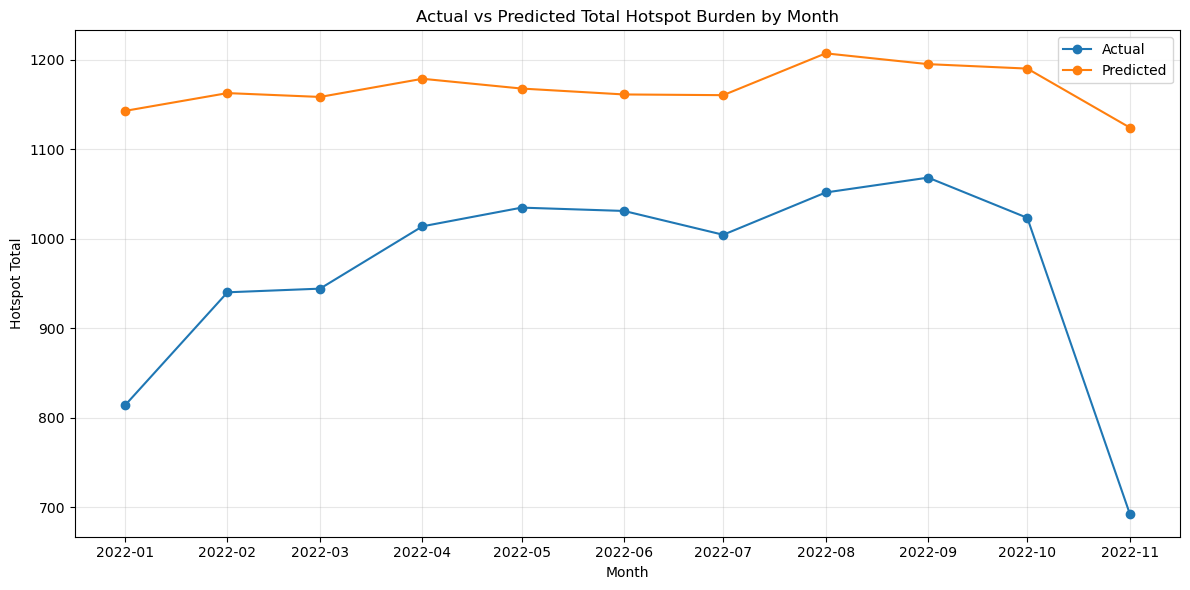

In [44]:
monthly_eval = (
    test_results.groupby("month_start", as_index=False)
    .agg(
        actual_total=("target_next_hotspot_total", "sum"),
        predicted_total=("pred_next_hotspot_total", "sum")
    )
)

plt.figure(figsize=(12, 6))
plt.plot(monthly_eval["month_start"], monthly_eval["actual_total"], marker="o", label="Actual")
plt.plot(monthly_eval["month_start"], monthly_eval["predicted_total"], marker="o", label="Predicted")
plt.title("Actual vs Predicted Total Hotspot Burden by Month")
plt.xlabel("Month")
plt.ylabel("Hotspot Total")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 13 Visualize top predicted cells for one test month:

,cell_id,lat_bin,lon_bin,month_start,target_next_hotspot_total,pred_next_hotspot_total,abs_error
954622,51.51_-0.13,51.51,-0.13,2022-11-01,1.067052,0.998464,0.068588
954670,51.51_-0.14,51.51,-0.14,2022-11-01,0.737870,0.631663,0.106207
967870,51.52_-0.17,51.52,-0.17,2022-11-01,0.530862,0.587836,0.056974
967726,51.52_-0.14,51.52,-0.14,2022-11-01,0.750857,0.564897,0.185960
224446,50.82_-0.14,50.82,-0.14,2022-11-01,0.121743,0.563184,0.441441
954430,51.51_-0.09,51.51,-0.09,2022-11-01,0.391927,0.544859,0.152932
1072222,51.5_-0.1,51.50,-0.10,2022-11-01,0.337838,0.518721,0.180884
967438,51.52_-0.08,51.52,-0.08,2022-11-01,0.874971,0.514542,0.360429
967822,51.52_-0.16,51.52,-0.16,2022-11-01,0.491489,0.511334,0.019845
930670,51.49_-0.1,51.49,-0.10,2022-11-01,0.305998,0.509060,0.203061


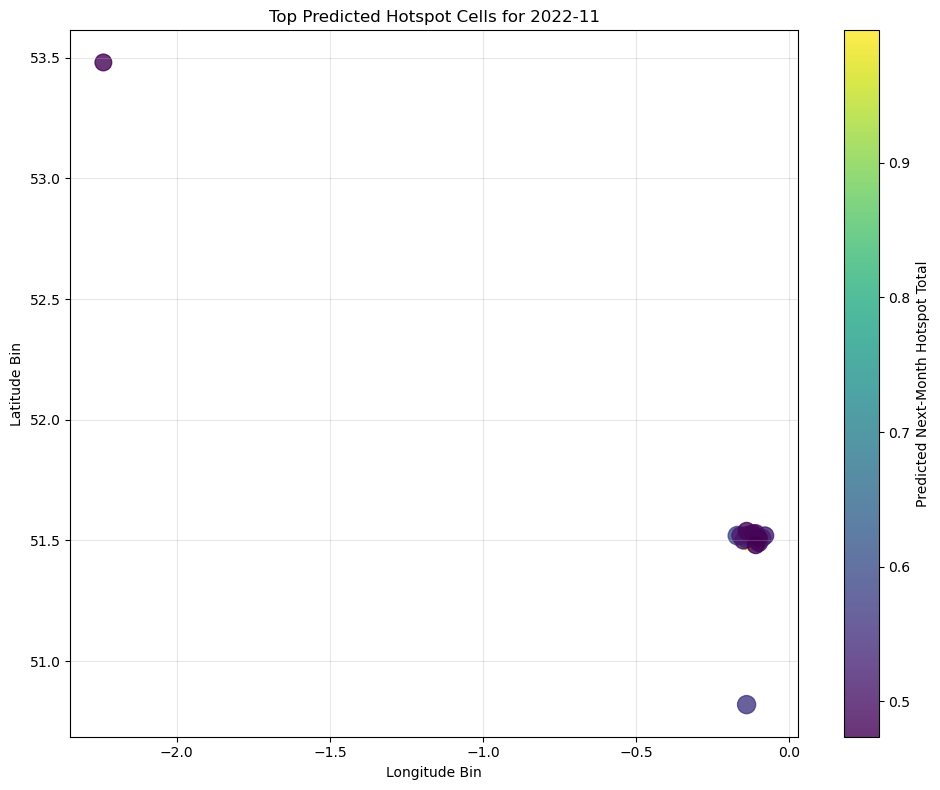

In [47]:
selected_month = test_results["month_start"].max()

month_view = test_results[test_results["month_start"] == selected_month].copy()
month_view = month_view.sort_values("pred_next_hotspot_total", ascending=False).head(20)

display(month_view)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    month_view["lon_bin"],
    month_view["lat_bin"],
    s=month_view["pred_next_hotspot_total"] * 300,
    c=month_view["pred_next_hotspot_total"],
    alpha=0.8
)
plt.colorbar(scatter, label="Predicted Next-Month Hotspot Total")
plt.xlabel("Longitude Bin")
plt.ylabel("Latitude Bin")
plt.title(f"Top Predicted Hotspot Cells for {pd.to_datetime(selected_month).strftime('%Y-%m')}")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 14 Forecast the next unseen month: 
This gives a real forward-looking forecast from the latest available data

In [53]:
# 14. Forecast the next unseen month:

# Use the latest month that has all required forecasting features
latest_feature_month = panel.dropna(subset=feature_cols)["month_start"].max()
forecast_month = latest_feature_month + pd.offsets.MonthBegin(1)

latest_rows = panel[
    (panel["month_start"] == latest_feature_month)
].dropna(subset=feature_cols).copy()

print("Latest feature month used for forecasting:", latest_feature_month)
print("Forecast month:", forecast_month)
print("Rows available for forecasting:", latest_rows.shape[0])

if latest_rows.empty:
    raise ValueError(
        "No rows available for forecasting. "
        "Check whether lag features were created correctly and whether enough history exists."
    )

future_pred = forecast_model.predict(latest_rows[feature_cols])

next_month_forecast = latest_rows[
    ["cell_id", "lat_bin", "lon_bin", "month_start"]
].copy()

next_month_forecast["forecast_month"] = forecast_month
next_month_forecast["pred_next_hotspot_total"] = future_pred

next_month_forecast = next_month_forecast.sort_values(
    "pred_next_hotspot_total", ascending=False
).reset_index(drop=True)

display(next_month_forecast.head(20))

Latest feature month used for forecasting: 2022-12-01 00:00:00
Forecast month: 2023-01-01 00:00:00
Rows available for forecasting: 85976


,cell_id,lat_bin,lon_bin,month_start,forecast_month,pred_next_hotspot_total
0,51.51_-0.13,51.51,-0.13,2022-12-01,2023-01-01,0.980176
1,50.82_-0.14,50.82,-0.14,2022-12-01,2023-01-01,0.722296
2,51.51_-0.09,51.51,-0.09,2022-12-01,2023-01-01,0.663179
3,51.51_-0.14,51.51,-0.14,2022-12-01,2023-01-01,0.610801
4,51.51_-0.15,51.51,-0.15,2022-12-01,2023-01-01,0.598484
5,51.52_-0.17,51.52,-0.17,2022-12-01,2023-01-01,0.529837
6,51.52_-0.14,51.52,-0.14,2022-12-01,2023-01-01,0.524610
7,51.52_-0.07,51.52,-0.07,2022-12-01,2023-01-01,0.521832
8,51.51_-0.12,51.51,-0.12,2022-12-01,2023-01-01,0.505601
9,51.5_-0.1,51.50,-0.10,2022-12-01,2023-01-01,0.500604


## Interactive future hotspot map

## 14A — Quick check and add priority bands

In [59]:
# 14A. Check forecast output and create priority bands

if "next_month_forecast" not in globals():
    raise ValueError("Run the fixed Cell 14 first so that next_month_forecast exists.")

if next_month_forecast.empty:
    raise ValueError("next_month_forecast is empty. Re-run the fixed Cell 14.")

forecast_viz = next_month_forecast.copy()

# Rank
forecast_viz["forecast_rank"] = range(1, len(forecast_viz) + 1)

# Create relative priority bands from forecast values
forecast_viz["priority_band"] = pd.qcut(
    forecast_viz["pred_next_hotspot_total"],
    q=4,
    labels=["Low", "Medium", "High", "Critical"],
    duplicates="drop"
)

print("Forecast month:", forecast_viz["forecast_month"].iloc[0])
print("Number of forecasted cells:", len(forecast_viz))

display(forecast_viz.head(20))

Forecast month: 2023-01-01 00:00:00
Number of forecasted cells: 85976


,cell_id,lat_bin,lon_bin,month_start,forecast_month,pred_next_hotspot_total,forecast_rank,priority_band
0,51.51_-0.13,51.51,-0.13,2022-12-01,2023-01-01,0.980176,1,Critical
1,50.82_-0.14,50.82,-0.14,2022-12-01,2023-01-01,0.722296,2,Critical
2,51.51_-0.09,51.51,-0.09,2022-12-01,2023-01-01,0.663179,3,Critical
3,51.51_-0.14,51.51,-0.14,2022-12-01,2023-01-01,0.610801,4,Critical
4,51.51_-0.15,51.51,-0.15,2022-12-01,2023-01-01,0.598484,5,Critical
5,51.52_-0.17,51.52,-0.17,2022-12-01,2023-01-01,0.529837,6,Critical
6,51.52_-0.14,51.52,-0.14,2022-12-01,2023-01-01,0.524610,7,Critical
7,51.52_-0.07,51.52,-0.07,2022-12-01,2023-01-01,0.521832,8,Critical
8,51.51_-0.12,51.51,-0.12,2022-12-01,2023-01-01,0.505601,9,Critical
9,51.5_-0.1,51.50,-0.10,2022-12-01,2023-01-01,0.500604,10,Critical


## 14D — Static hotspot bubble map:

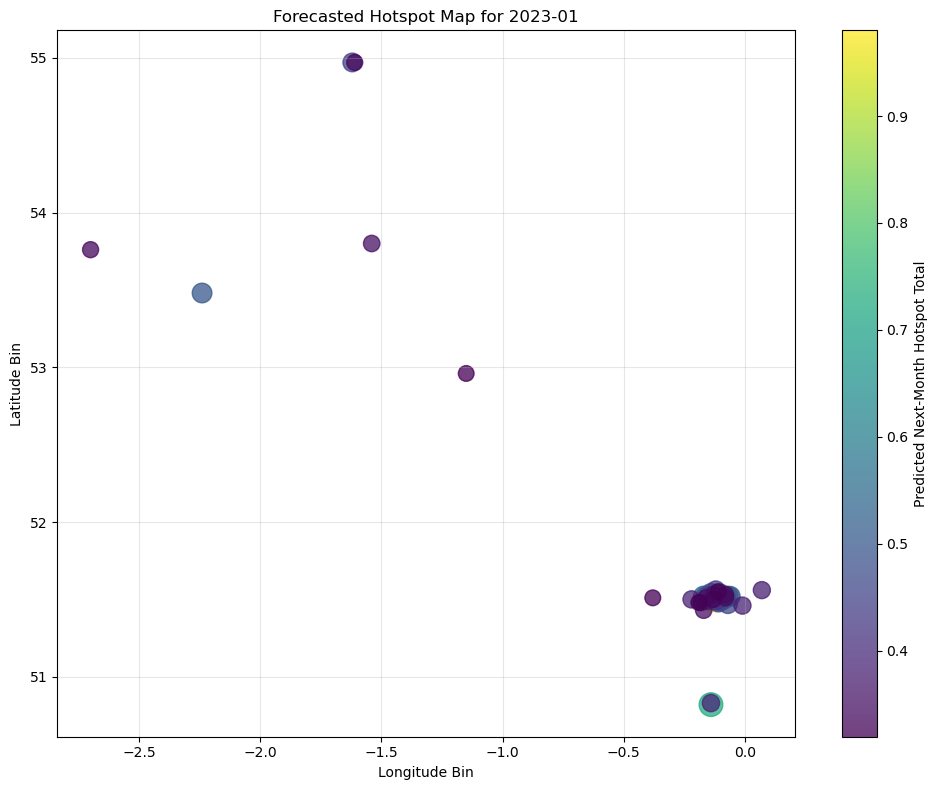

In [65]:
# 14D. Static bubble map of next-month forecast

top_map = forecast_viz.head(50).copy()   # visualize top 50 predicted cells

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    top_map["lon_bin"],
    top_map["lat_bin"],
    s=top_map["pred_next_hotspot_total"] * 400,
    c=top_map["pred_next_hotspot_total"],
    alpha=0.75
)

plt.colorbar(scatter, label="Predicted Next-Month Hotspot Total")
plt.xlabel("Longitude Bin")
plt.ylabel("Latitude Bin")
plt.title(
    f"Forecasted Hotspot Map for "
    f"{pd.to_datetime(top_map['forecast_month'].iloc[0]).strftime('%Y-%m')}"
)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 14E. Interactive map for the next forecast month

In [62]:
import folium
from folium.plugins import MarkerCluster

center_lat = forecast_viz["lat_bin"].mean()
center_lon = forecast_viz["lon_bin"].mean()

future_map = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=6,
    tiles="CartoDB positron"
)

marker_cluster = MarkerCluster().add_to(future_map)

top_interactive = forecast_viz.head(100).copy()

for _, row in top_interactive.iterrows():
    score = row["pred_next_hotspot_total"]

    if row["priority_band"] == "Critical":
        color = "darkred"
    elif row["priority_band"] == "High":
        color = "orange"
    elif row["priority_band"] == "Medium":
        color = "blue"
    else:
        color = "green"

    popup_text = f"""
    <b>Forecast Rank:</b> {row['forecast_rank']}<br>
    <b>Cell ID:</b> {row['cell_id']}<br>
    <b>Forecast Month:</b> {pd.to_datetime(row['forecast_month']).strftime('%Y-%m')}<br>
    <b>Predicted Next Hotspot Total:</b> {row['pred_next_hotspot_total']:.4f}<br>
    <b>Priority Band:</b> {row['priority_band']}<br>
    <b>Latitude Bin:</b> {row['lat_bin']}<br>
    <b>Longitude Bin:</b> {row['lon_bin']}
    """

    folium.CircleMarker(
        location=[row["lat_bin"], row["lon_bin"]],
        radius=max(5, min(18, row["pred_next_hotspot_total"] * 10)),
        color=color,
        fill=True,
        fill_opacity=0.7,
        popup=folium.Popup(popup_text, max_width=320)
    ).add_to(marker_cluster)

future_map

# 14G Summary by priority band

In [72]:
# 14G. Summary by priority band
band_summary = (
    forecast_viz.groupby("priority_band", as_index=False)
    .agg(
        num_cells=("cell_id", "size"),
        mean_forecast_hotspot=("pred_next_hotspot_total", "mean"),
        total_forecast_hotspot=("pred_next_hotspot_total", "sum")
    )
)

display(band_summary)

,priority_band,num_cells,mean_forecast_hotspot,total_forecast_hotspot
0,Low,21503,0.004160,89.460546
1,Medium,21490,0.006082,130.705406
2,High,21489,0.009337,200.650636
3,Critical,21494,0.032011,688.043243


# 15 Save outputs:

In [76]:
from pathlib import Path

out_dir = Path("hotspot_forecasting_outputs")
out_dir.mkdir(exist_ok=True)

panel.to_csv(out_dir / "cell_month_panel.csv", index=False)
model_df.to_csv(out_dir / "forecast_model_dataset.csv", index=False)
test_results.to_csv(out_dir / "test_hotspot_forecasts.csv", index=False)
next_month_forecast.to_csv(out_dir / "next_month_hotspot_forecast.csv", index=False)
top10_hits.to_csv(out_dir / "top10_hit_rate_by_month.csv", index=False)

forecast_model.save_model(str(out_dir / "catboost_hotspot_forecaster.cbm"))

print("Saved outputs to:", out_dir.resolve())

Saved outputs to: C:\Users\User\Desktop\UK Road Accident Project\hotspot_forecasting_outputs
